In [165]:
import pandas as pd
import numpy as np

In [166]:
df = pd.read_csv('../Data/Churn_Modelling.xls')

In [167]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [168]:
df.shape 

(10000, 14)

In [169]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [170]:
df.duplicated().sum()

np.int64(0)

In [171]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [172]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [173]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [174]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [175]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [176]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [177]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [178]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [179]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [180]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [181]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [182]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

### 11 Inputs
###    ↓
### Hidden Layer (3 neurons)
###   ↓
### Output Layer (1 neuron)

In [183]:
model = Sequential()

model.add(Input(shape=(11,)))
model.add(Dense(3, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [184]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [185]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [186]:
history = model.fit(X_train_scaled, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7695 - loss: 0.5872 - val_accuracy: 0.7975 - val_loss: 0.5390
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.7972 - loss: 0.5149 - val_accuracy: 0.7975 - val_loss: 0.4936
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.7972 - loss: 0.4811 - val_accuracy: 0.7975 - val_loss: 0.4723
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - accuracy: 0.7972 - loss: 0.4633 - val_accuracy: 0.7975 - val_loss: 0.4600
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.7972 - loss: 0.4519 - val_accuracy: 0.7975 - val_loss: 0.4516
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.7978 - loss: 0.4440 - val_accuracy: 0.7981 - val_loss: 0.4458
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - accuracy: 0.7992 - loss: 0.4384 - val_accuracy: 0.8012 - val_loss: 0.4416
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.8009 - loss: 0.4344 - va

In [187]:
model.layers[0].get_weights()

[array([[ 0.10547367,  0.08971347,  0.15595403],
        [ 1.5073409 , -0.7366934 , -1.2960042 ],
        [ 0.28362128,  0.25951305, -0.00463722],
        [ 0.42997423, -0.17334644, -0.10009495],
        [-0.4284126 , -0.09507385,  0.12028323],
        [ 0.2513506 ,  0.34146082, -0.03233813],
        [-0.74205214,  0.7893228 ,  0.48300207],
        [ 0.24151665, -0.12410395, -0.02409386],
        [ 0.47112933, -0.27264526, -0.6699736 ],
        [-0.34333032, -0.3370694 ,  0.11746198],
        [-0.33600247,  0.4877572 ,  0.3196208 ]], dtype=float32),
 array([-0.47909507,  0.503707  ,  0.48813102], dtype=float32)]

In [188]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step


In [189]:
y_log

array([[0.11101443],
       [0.13741569],
       [0.14200792],
       ...,
       [0.07293612],
       [0.1394728 ],
       [0.3112076 ]], shape=(2000, 1), dtype=float32)

In [190]:
y_pred = np.where(y_log>0.5,1,0)

In [191]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [192]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8095

In [193]:
import matplotlib.pyplot as plt

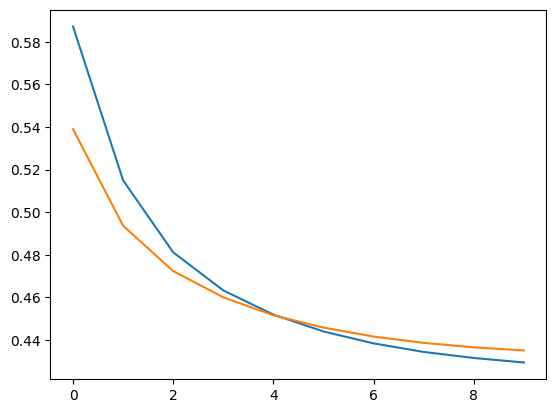

In [195]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])